### 1. Import Packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import norm

### 2. Functions Definition

In [2]:
def black_scholes(forward, strike, time_to_expiry, volatility, option_type="call"):
    """Simple European Black‑Scholes (no discounting)."""
    if time_to_expiry <= 0:
        if option_type.lower().startswith("c"):
            return max(forward - strike, 0.0)
        return max(strike - forward, 0.0)
    vol_sqrt_t = volatility * np.sqrt(time_to_expiry)
    d1 = (np.log(forward / strike) + 0.5 * volatility**2 * time_to_expiry) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t
    if option_type.lower().startswith("c"):
        return norm.cdf(d1) * forward - norm.cdf(d2) * strike
    else:
        return norm.cdf(-d2) * strike - norm.cdf(-d1) * forward

def implied_vol_proxy(rv, base=0.20, skew_slope=-0.25):
    """
    rv: realized vol
    base: long-term IV anchor
    skew_slope: controls downside skew
    """
    return base + 0.5 * rv

def strike_from_delta(S, T, sigma, delta=0.25, call=True):
    sign = 1 if call else -1
    d1 = sign * norm.ppf(delta)
    return S * np.exp(
        -sigma * np.sqrt(T) * d1 + 0.5 * sigma**2 * T
    )

def option_vega(S, K, T, sigma):
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

# P&L engine
def option_pnl_series(S, K, T, sigma_series, vega_notional):
    prices = []
    
    for sigma in sigma_series:
        price = black_scholes(
            forward=S,
            strike=K,
            time_to_expiry=T,
            volatility=sigma,
            option_type="call"
        )
        prices.append(price)
    
    prices = pd.Series(prices, index=sigma_series.index)
    pnl = prices.diff().fillna(0)

    vega = option_vega(S, K, T, sigma_series.iloc[0])
    scale = vega_notional / vega

    return pnl * scale

### 3. Universe Definition

In [3]:
# Index + top 10 IBOV names (example tickers)
INDEX = "^BVSP"

SINGLES = [
    "PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "ABEV3.SA",
    "BBAS3.SA", "WEGE3.SA", "RENT3.SA", "SUZB3.SA", "JBSS3.SA"
]

### 4. Obtain Price Data

In [4]:
tickers = [INDEX] + SINGLES

prices = yf.download(
    tickers,
    start="2022-01-01",
    auto_adjust=True
)["Close"]

prices = prices.dropna(axis=1, how="any")

returns = np.log(prices / prices.shift(1))
returns

[**********************82%**************         ]  9 of 11 completed$JBSS3.SA: possibly delisted; no timezone found
[*********************100%***********************]  10 of 11 completed

1 Failed download:
[*********************100%***********************]  10 of 11 completed['JBSS3.SA']: possibly delisted; no timezone found


Ticker,ABEV3.SA,BBAS3.SA,BBDC4.SA,ITUB4.SA,PETR4.SA,RENT3.SA,SUZB3.SA,VALE3.SA,WEGE3.SA,^BVSP
Date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.001305,0.001040,0.006535,0.027964,0.003774,0.005682,0.021581,-0.011865,-0.005009,-0.003934
2022-01-05,-0.019790,-0.016778,-0.007095,-0.019170,-0.039467,-0.029344,-0.011397,0.009426,-0.054172,-0.024527
2022-01-06,-0.016119,0.008074,0.014142,0.020073,-0.000713,0.003816,-0.008005,0.019977,-0.000331,0.005480
2022-01-07,-0.016383,0.001048,0.014439,0.021891,0.004624,-0.008454,-0.006720,0.056571,-0.025513,0.011338
...,...,...,...,...,...,...,...,...,...,...
2026-03-18,-0.018818,-0.011045,-0.011740,-0.010119,0.013279,-0.011496,-0.010410,-0.023449,-0.000866,-0.004277
2026-03-19,0.002033,0.004263,0.000537,0.007071,-0.004692,0.007003,-0.027780,-0.006504,0.009272,0.003506
2026-03-20,-0.020521,-0.010261,-0.016771,-0.016260,-0.024014,-0.027618,-0.018559,-0.014194,-0.013614,-0.022734


### 5. Set RV Window

In [5]:
RV_WINDOW = 42

realized_vol = returns.rolling(RV_WINDOW, min_periods=1).std() * np.sqrt(252)

realized_vol

Ticker,ABEV3.SA,BBAS3.SA,BBDC4.SA,ITUB4.SA,PETR4.SA,RENT3.SA,SUZB3.SA,VALE3.SA,WEGE3.SA,^BVSP
Date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-05,0.207484,0.200009,0.153002,0.529078,0.485385,0.393170,0.370175,0.238987,0.551850,0.231158
2022-01-06,0.155344,0.203354,0.170810,0.400754,0.377437,0.312817,0.287967,0.257481,0.473479,0.243618
2022-01-07,0.130709,0.168483,0.160124,0.341396,0.335660,0.255831,0.242440,0.454199,0.389210,0.249608
...,...,...,...,...,...,...,...,...,...,...
2026-03-18,0.236608,0.339620,0.299125,0.313069,0.264355,0.400913,0.379191,0.346207,0.311733,0.223757
2026-03-19,0.236492,0.339252,0.299125,0.312414,0.266556,0.392910,0.383717,0.346507,0.312514,0.223171
2026-03-20,0.242333,0.340461,0.301835,0.315431,0.278369,0.399579,0.386094,0.348005,0.314286,0.231319


### 6. Index/Singles Legs & Total P&L

In [6]:
T = 2 / 12  # 2 months

ibov_pnl = []
single_pnl = []

for date in realized_vol.index[RV_WINDOW:]:
    S = prices.loc[date, INDEX]
    sigma_today = implied_vol_proxy(realized_vol.loc[date, INDEX])
    K = strike_from_delta(S, T, sigma_today)

    # use sigma series starting at `date` so sigma_series.iloc[0] is not NaN
    sigma_series_slice = realized_vol[INDEX].loc[date:].dropna()
    if sigma_series_slice.empty:
        continue

    pnl = option_pnl_series(
        S,
        K,
        T,
        sigma_series_slice,
        vega_notional=100_000,
    )

    ibov_pnl.append(pnl)

# concatenate and sum across columns (skipna=True);
if ibov_pnl:
    ibov_pnl = pd.concat(ibov_pnl, axis=1).sum(axis=1)
else:
    ibov_pnl = pd.Series(dtype=float)

# Allocation across singles (vega-neutral?)
iterator = [c for c in prices.columns if c != INDEX and c in realized_vol.columns]

per_name_vega = -100_000 / len(iterator)

single_series_list = []
for name in iterator:
    S_mean = prices[name].mean()
    sigma_series = realized_vol[name].iloc[RV_WINDOW:].dropna()
    if sigma_series.empty:
        continue
    sigma_proxy = implied_vol_proxy(sigma_series.iloc[0])
    K = strike_from_delta(S_mean, T, sigma_proxy.mean() if np.ndim(sigma_proxy)>0 else sigma_proxy)

    pnl = option_pnl_series(
        S_mean,
        K,
        T,
        sigma_series,
        vega_notional=per_name_vega,
    )
    single_series_list.append(pnl)

if single_series_list:
    single_pnl = pd.concat(single_series_list, axis=1).sum(axis=1)
else:
    single_pnl = pd.Series(dtype=float)

# align and add
total_pnl = ibov_pnl.add(single_pnl, fill_value=0)
cum_pnl = total_pnl.cumsum()

### 7. Plot Results

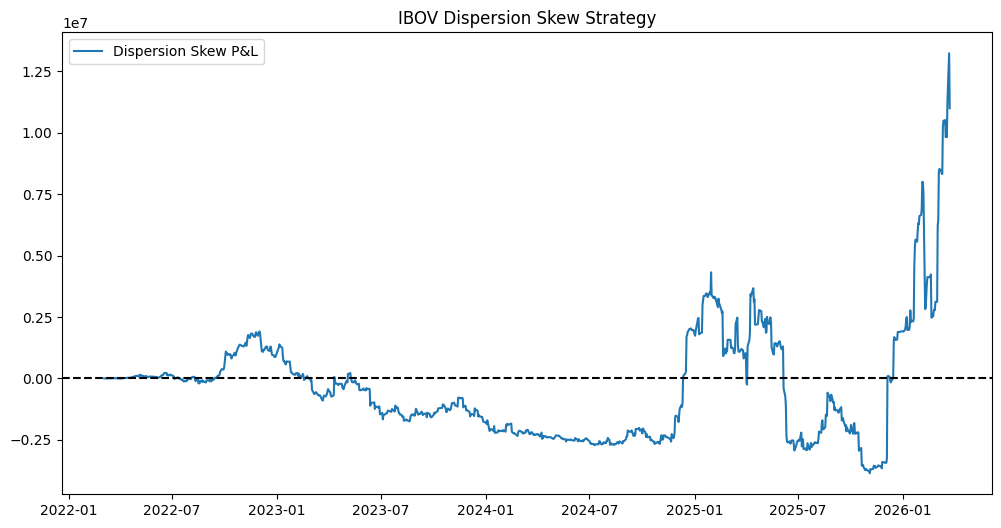

In [7]:
plt.figure(figsize=(12,6))
plt.plot(cum_pnl, label="Dispersion Skew P&L") # singles_pnl.cumsum() @ diff scale
plt.axhline(0, linestyle="--", color="black")
plt.legend()
plt.title("IBOV Dispersion Skew Strategy")
plt.show()

### 8. Testing Grounds

In [8]:
# compute a representative index vega (use today's/first trade date vega used for ibov sizing)
# here we take vega of the first ibov pnl series if available, otherwise compute from spot
if isinstance(ibov_pnl, pd.Series) and not ibov_pnl.empty:
    # pick first trade date used to size ibov; better: compute ibov_vega explicitly when creating ibov positions
    ibov_total_vega = 100_000  # keep as notional target (or compute actual ibov vega if you prefer)
else:
    ibov_total_vega = 100_000

# compute per-stock vegas and allocate proportionally so sum(per_name_vega * vega_i) ~= -ibov_total_vega
vegas = {}
for name in iterator:
    # use a representative sigma (first non-nan) and a representative S (current spot or mean)
    sigma_rep = realized_vol[name].iloc[RV_WINDOW:].dropna()
    if sigma_rep.empty:
        continue
    sigma0 = sigma_rep.iloc[0]
    S_rep = prices[name].iloc[RV_WINDOW] if not np.isnan(prices[name].iloc[RV_WINDOW]) else prices[name].mean()
    # choose strike K similarly (you already use strike_from_delta)
    K_rep = strike_from_delta(S_rep, T, implied_vol_proxy(sigma0))
    vegas[name] = option_vega(S_rep, K_rep, T, sigma0)

vega_sum = sum(abs(v) for v in vegas.values()) or 1.0

single_series_list = []
for name in iterator:
    if name not in vegas:
        continue
    # allocate vega notional proportionally (negative to offset index)
    per_name_vega_notional = -ibov_total_vega * (abs(vegas[name]) / vega_sum)
    # align sigma_series to the same date range you want
    sigma_series = realized_vol[name].iloc[RV_WINDOW:].dropna()
    if sigma_series.empty:
        continue
    # use spot series or S at trade dates (avoid using global mean if you want time alignment)
    S_series = prices[name].loc[sigma_series.index]
    # create pnl using spot series aligned to sigma_series: change option_pnl_series to accept S_series if needed
    # for simplicity keep using a fixed S_rep (but prefer using S_series for time alignment)
    S_rep = prices[name].loc[sigma_series.index[0]]
    K = strike_from_delta(S_rep, T, implied_vol_proxy(sigma_series.iloc[0]))
    pnl = option_pnl_series(
        S_rep,
        K,
        T,
        sigma_series,
        vega_notional=per_name_vega_notional,
    )
    single_series_list.append(pnl)

In [9]:
if single_series_list:
    single_pnl = pd.concat(single_series_list, axis=1).sum(axis=1)
else:
    single_pnl = pd.Series(dtype=float)

# align and add
total_pnl = ibov_pnl.add(single_pnl, fill_value=0)
cum_pnl = total_pnl.cumsum()

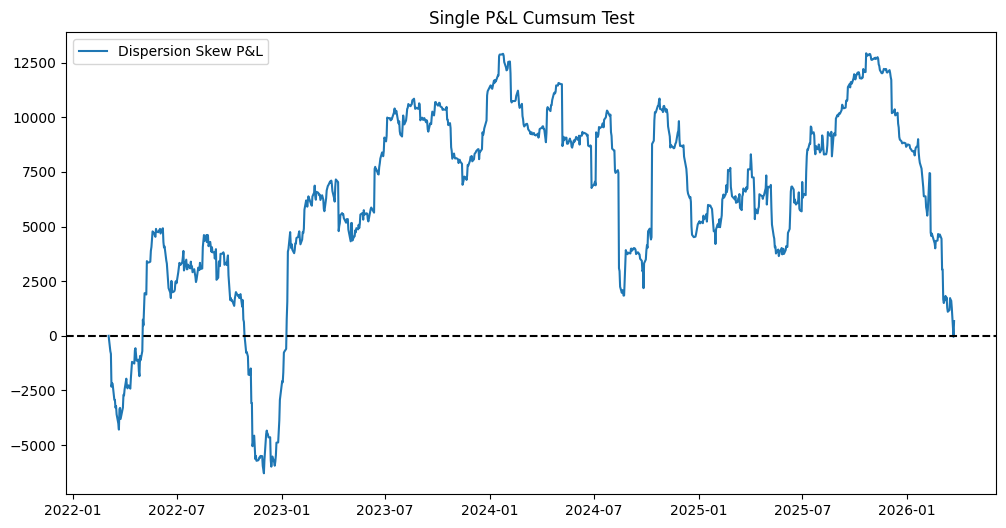

In [10]:
plt.figure(figsize=(12,6))
plt.plot(single_pnl.cumsum(), label="Dispersion Skew P&L") # singles_pnl.cumsum() @ diff scale
plt.axhline(0, linestyle="--", color="black")
plt.legend()
plt.title("Single P&L Cumsum Test")
plt.show()

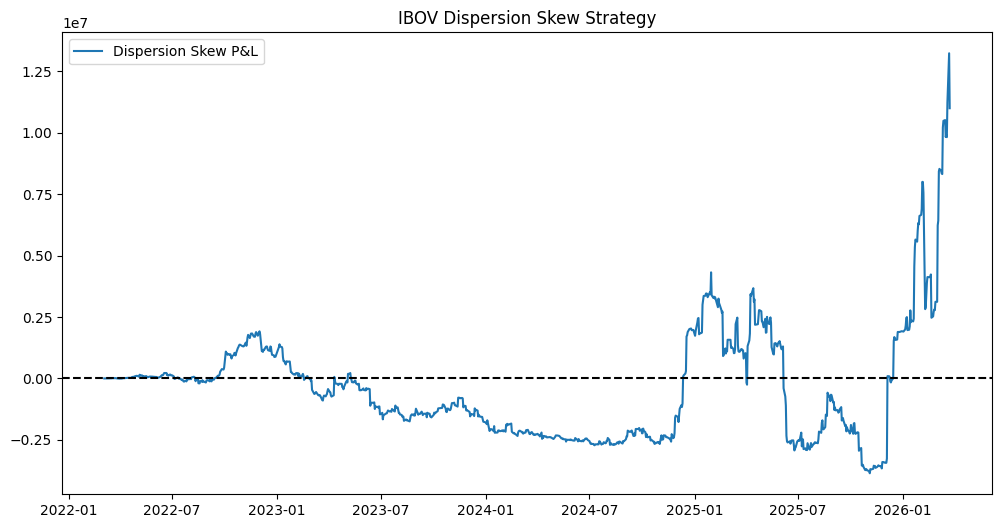

In [11]:
plt.figure(figsize=(12,6))
plt.plot(cum_pnl, label="Dispersion Skew P&L") # singles_pnl.cumsum() @ diff scale
plt.axhline(0, linestyle="--", color="black")
plt.legend()
plt.title("IBOV Dispersion Skew Strategy")
plt.show()

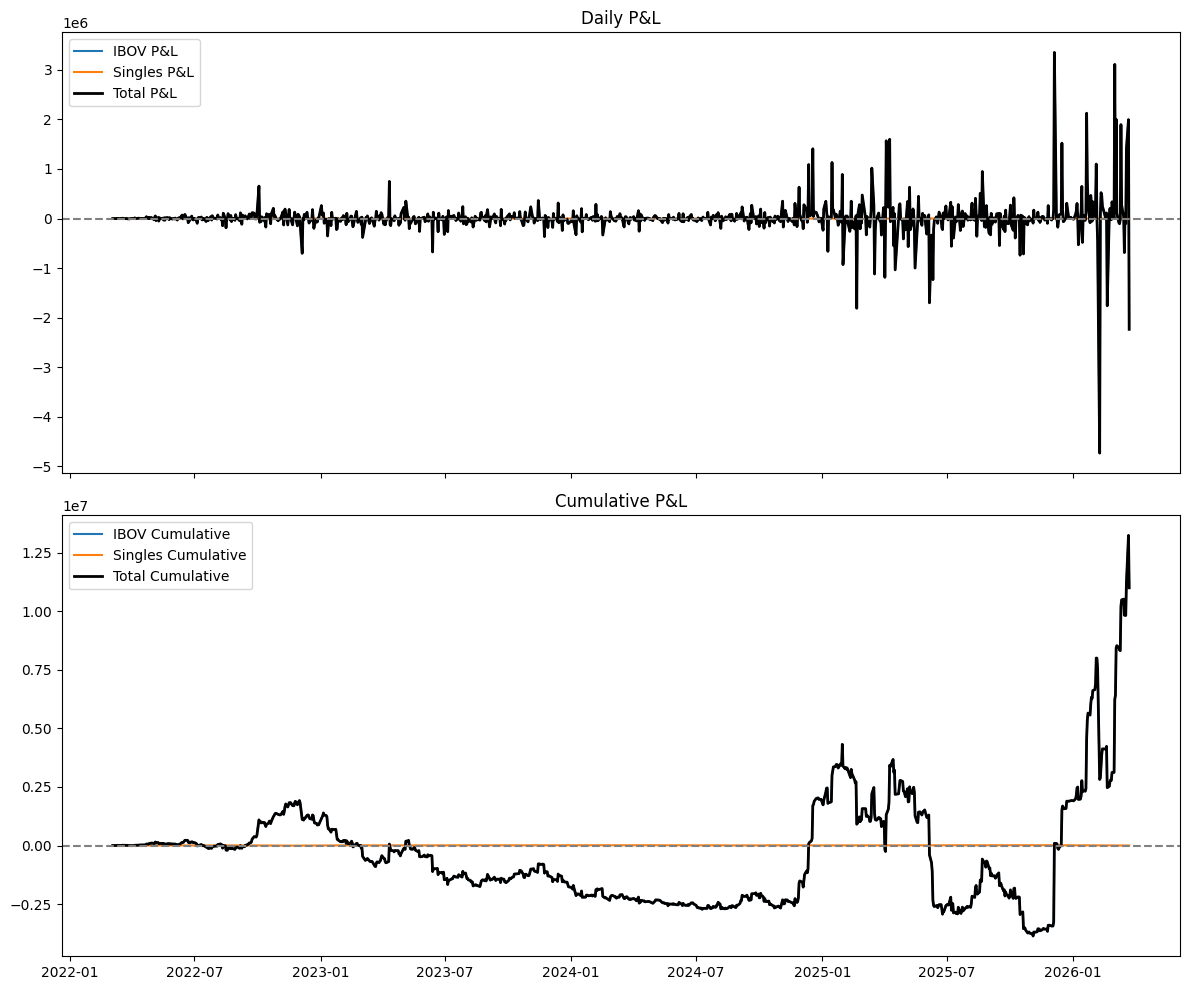

In [12]:
# new plotting cell: show legs and total (daily + cumulative)
df = pd.concat(
    [
        ibov_pnl.rename("ibov_pnl") if isinstance(ibov_pnl, pd.Series) else pd.Series(dtype=float),
        single_pnl.rename("single_pnl") if isinstance(single_pnl, pd.Series) else pd.Series(dtype=float),
        total_pnl.rename("total_pnl") if isinstance(total_pnl, pd.Series) else pd.Series(dtype=float),
    ],
    axis=1,
).fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Daily P&L
axes[0].plot(df.index, df["ibov_pnl"], label="IBOV P&L")
axes[0].plot(df.index, df["single_pnl"], label="Singles P&L")
axes[0].plot(df.index, df["total_pnl"], label="Total P&L", linewidth=2, color="black")
axes[0].axhline(0, linestyle="--", color="gray")
axes[0].legend()
axes[0].set_title("Daily P&L")

# Cumulative P&L
axes[1].plot(df.index, df["ibov_pnl"].cumsum(), label="IBOV Cumulative")
axes[1].plot(df.index, df["single_pnl"].cumsum(), label="Singles Cumulative")
axes[1].plot(df.index, df["total_pnl"].cumsum(), label="Total Cumulative", linewidth=2, color="black")
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].legend()
axes[1].set_title("Cumulative P&L")

plt.tight_layout()
plt.show()

In [13]:
df

,ibov_pnl,single_pnl,total_pnl
Date,,,
2022-03-04,0.000000e+00,0.000000,0.000000e+00
2022-03-07,1.446202e+03,-701.435822,7.447661e+02
2022-03-08,-2.541737e+03,-125.295335,-2.667032e+03
2022-03-09,2.578388e+03,-1502.041981,1.076346e+03
2022-03-10,-4.210280e+02,163.602726,-2.574252e+02
...,...,...,...
2026-03-18,9.298542e+04,-150.310495,9.283511e+04
2026-03-19,-1.005149e+05,36.772122,-1.004781e+05
2026-03-20,1.417950e+06,-330.664776,1.417619e+06
